# Optimization over the surrogate models 


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch 
from torch import nn
from torch.utils.data import DataLoader, Dataset

data_directory = "../Data/unh_hackathon_prompt_2_data.json"
sys.path.append("../UNH-Hackathon-2026-Group-3/")

First, we have to construct the models. 

In [26]:
def load_predictive_warfighting_data(file_path: str = "unh_hackathon_prompt_2_data.json") -> pd.DataFrame:
    """Load data from a CSV file into a pandas DataFrame."""
    return pd.read_json(file_path)

def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """Clean the DataFrame by converting data types."""

    # Convert the string "NULL" to pd.NA
    df = df.replace("NULL", pd.NA)
    df = df.replace("N/A", pd.NA)

    for numeric_string_column in [
        "Enemy.Capability.Index",
        "EW_Capability",
        "Intel Confidence",

    ]:
        df[numeric_string_column] = pd.to_numeric(df[numeric_string_column])

    for boolean_string_column in [
        "response_success"
    ]:
        df[boolean_string_column] = df[boolean_string_column].map({"Yes": 1, "No": 0, "1": 1, "0": 0})

    # clean labels in threat type column 
    df["Threat Type"] = df["Threat Type"].str.strip()  # Remove leading/trailing whitespace
    df["Threat Type"] = df["Threat Type"].str.lower()  # Convert to lowercase for consistency
    df["Threat Type"] = df["Threat Type"].replace({"msl": "missile"})

    return df

In [27]:
dirty_df = load_predictive_warfighting_data(data_directory)
df = clean_data(dirty_df)

# remove rows with nan values in any column 
df = df.dropna()

In [28]:
# filter by threat type here, before dropping nas 
df = df[df["Threat Type"] == "naval"]

In [29]:
# get array of values for input variables:
''' 
every column except output/results and categorical variables 
- also remove columns with nan values 
'''
input_columns = df.select_dtypes(include=[np.number]).columns.tolist()
input_columns.remove('response_success')
input_columns.remove('Financial_Loss_MUSD')
input_columns.remove('actual_days_to_stabilization')
input_columns = [col for col in input_columns if not df[col].isna().any()]
inputs = df[input_columns].values


# get array of values for output variables:
response_successes = df['response_success'].values
financial_loss_musds = df['Financial_Loss_MUSD'].values
actual_days_to_stabilizations = df['actual_days_to_stabilization'].values

output0 = response_successes
output1 = financial_loss_musds
output2 = actual_days_to_stabilizations

outputs = np.column_stack((output0, output1, output2))

# print(output0[0], output1[0], output2[0])

In [30]:
# get the min and max of each input variable for setting constraints in optimization
input_mins = np.min(inputs, axis=0)
input_maxs = np.max(inputs, axis=0)
print(input_mins)
print(input_maxs)

[1.000e+00 1.000e+00 1.000e+00 5.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 2.000e-01 1.000e+00 0.000e+00 4.000e-01 0.000e+00
 4.000e+01 3.000e-01 1.000e+00 0.000e+00 1.000e+00 1.000e+00 5.000e+01
 6.000e+01 0.000e+00 5.049e+02]
[5.0000e+01 1.0000e+01 7.2000e+01 6.0000e+01 8.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 1.5000e+01 1.0000e+00 1.0000e+01 1.0000e+01
 1.0000e+00 2.5000e+01 1.0000e+02 1.0000e+00 4.8000e+01 2.4000e+01
 1.0000e+01 5.0000e+00 5.0000e+02 1.0000e+02 1.0000e+01 9.9815e+03]


In [31]:
# min of financial loss 
print(np.min(financial_loss_musds))

123


In [32]:
# metrics function 
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
def calculate_metrics(true_values, predictions):
    mae = mean_absolute_error(true_values, predictions)
    r2 = r2_score(true_values, predictions)
    rmse = np.sqrt(mean_squared_error(true_values, predictions))

    mae = mean_absolute_error(true_values, predictions)
    r2 = r2_score(true_values, predictions)
    rmse = np.sqrt(mean_squared_error(true_values, predictions))
    mape = np.mean(np.abs((true_values - predictions) / true_values)) * 100

    print(f"Mean Absolute Error (MAE): {mae:.6f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
    print(f"R² Score: {r2:.6f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")  
    return mae, r2, rmse, mape

In [33]:
# train test split for all inputs and outputs 
X_train, X_test, Y_train, Y_test = train_test_split(inputs, outputs, test_size=0.2, random_state=42)

# standardize 
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## ElasticNetCV model for y1: financial_loss_musds


In [34]:
y1_train = Y_train[:, 1] # financial loss
y1_test = Y_test[:, 1]

In [35]:
from sklearn.linear_model import ElasticNetCV
X = X_train_scaled
y = y1_train
regr1 = ElasticNetCV(cv=5, random_state=0)
regr1.fit(X, y)
print(regr1.alpha_)
print(regr1.intercept_)
print(regr1.predict([[0]*24]))

calculate_metrics(y1_test, regr1.predict(X_test_scaled))

0.07147949894951695
321.2264462809918
[321.22644628]
Mean Absolute Error (MAE): 22.161376
Root Mean Squared Error (RMSE): 29.859619
R² Score: 0.860326
Mean Absolute Percentage Error (MAPE): 7.07%


(22.161375810917672,
 0.8603262664105535,
 np.float64(29.85961945796274),
 np.float64(7.070651585214425))

## ElasticNetCV model for y2: actual_days_to_stabilizations

In [36]:
# get min of days to neutralization:
min_days_to_neutralization = np.min(Y_train[:, 2])
print("Min days to neutralization in training set:", min_days_to_neutralization)

Min days to neutralization in training set: 2.0


In [37]:
y2_train = Y_train[:, 2] # days to stabilization
y2_test = Y_test[:, 2]

In [38]:
from sklearn.linear_model import ElasticNetCV
X = X_train_scaled
y = y2_train
regr2 = ElasticNetCV(cv=5, random_state=0)
regr2.fit(X, y)
print(regr2.alpha_)
print(regr2.intercept_)
print(regr2.predict([[0]*24]))

0.0077345532871958235
9.712396694214878
[9.71239669]


In [39]:
calculate_metrics(y2_test, regr2.predict(X_test_scaled))

Mean Absolute Error (MAE): 1.364148
Root Mean Squared Error (RMSE): 1.785493
R² Score: 0.864203
Mean Absolute Percentage Error (MAPE): 20.28%


(1.3641479683859805,
 0.8642031321782833,
 np.float64(1.7854933230232486),
 np.float64(20.27524880726516))

## Multi-Objective Optimization 

In [40]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.core.problem import ElementwiseProblem
from pymoo.visualization.scatter import Scatter
from pymoo.visualization.fitness_landscape import FitnessLandscape
from pymoo.core.repair import Repair 

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       80 |      2 |             - |             -
     2 |      160 |      4 |  0.1120271155 |         ideal
     3 |      240 |      4 |  0.0937586654 |         nadir
     4 |      320 |      3 |  0.1534445613 |         ideal
     5 |      400 |      5 |  0.0780743624 |         ideal
     6 |      480 |      6 |  0.0139949949 |             f
     7 |      560 |      6 |  0.1165566333 |         ideal
     8 |      640 |      5 |  0.0050284433 |         ideal
     9 |      720 |      5 |  0.0470518625 |         nadir
    10 |      800 |      6 |  0.0605346401 |         ideal
    11 |      880 |      7 |  0.1124096301 |         ideal
    12 |      960 |      8 |  0.0579516023 |         ideal
    13 |     1040 |      9 |  0.0528654218 |             f
    14 |     1120 |     11 |  0.0619776016 |         ideal
    15 |     1200 |     12 |  0.0025005831 |         ideal
    16 |     1280 |      7 |  0.0241232123 |            

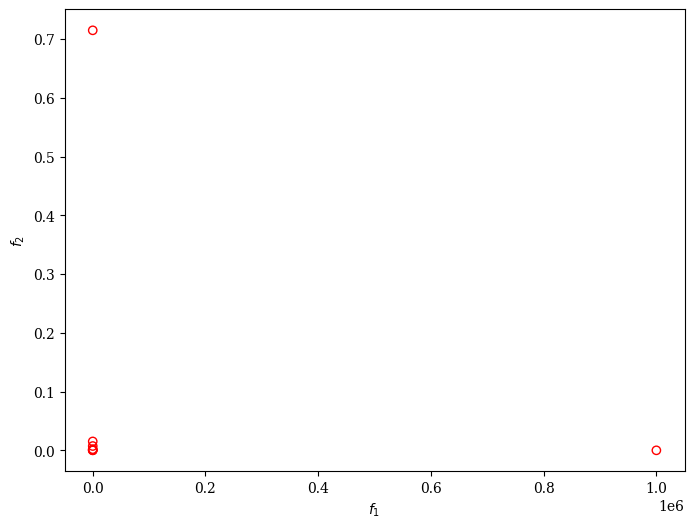

In [41]:
from pymoo.core.problem import Problem

penalty = 1e6
min_y2 = min_days_to_neutralization

class RiskAnalysisVecProblem(Problem):
    def __init__(self):
        xl = input_mins.copy()
        xu = input_maxs.copy()
        super().__init__(n_var=inputs.shape[1], n_obj=2, xl=xl, xu=xu, elementwise_evaluation=False)

    def _evaluate(self, X, out, *args, **kwargs):
        Xs = np.atleast_2d(X)
        Xs_scaled = scaler.transform(Xs)
        y1s = regr1.predict(Xs_scaled)
        y2s = regr2.predict(Xs_scaled)
        # penalty logic vectorized:
        y1s = np.where(y1s < 0, penalty + np.abs(y1s), y1s) 
        y2s = np.where(y2s < 0, penalty + np.abs(y2s), y2s)
        out["F"] = np.column_stack([y1s, y2s])

problem = RiskAnalysisVecProblem()
algorithm = NSGA2(pop_size=80)
res = minimize(problem, algorithm, ('n_gen', 80), verbose=True)

# graph pareto front 
plot = Scatter()
plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")
plot.show()

In [42]:
# print input vector associate with pareto optimal solutions
pareto_optimal_inputs = res.X
pareto_optimal_outputs = res.F
print("Pareto optimal input vectors:")
for i, input_vector in enumerate(pareto_optimal_inputs):
    print(f"Solution {i+1}:")
    print(f"Optimal point {i+1}: {pareto_optimal_outputs[i]}")
    print(f"Input Vector: {input_vector}\n")
    

Pareto optimal input vectors:
Solution 1:
Optimal point 1: [0.0009616  0.71522072]
Input Vector: [3.52902825e+00 1.17208936e+00 1.11895741e+01 3.06474244e+01
 4.40238441e-03 0.00000000e+00 0.00000000e+00 0.00000000e+00
 5.77235138e-01 7.59497682e-01 6.51008669e+00 7.63009540e+00
 4.24352030e-01 1.68051909e+01 9.25396935e+01 8.37396467e-01
 1.08066137e+00 5.88968308e-01 7.62951203e+00 1.12460258e+00
 5.00782206e+01 7.51879577e+01 8.05849663e-01 5.34790016e+02]

Solution 2:
Optimal point 2: [0.00400102 0.00730928]
Input Vector: [  3.77656529   1.17413287  11.05998613  58.46452169   0.69018923
   0.           0.           0.           0.6824789    0.74309225
   7.81733612   7.64420922   0.63985277  16.80942727  93.88561226
   0.93760125   1.03673691   0.58280983   7.52809035   1.11945244
  52.73747335  74.90059374   0.81613457 531.39101996]

Solution 3:
Optimal point 3: [3.56902732e-01 3.07119691e-05]
Input Vector: [  1.84820056   1.17154626  11.05977289  56.45756287   0.69018923
   0.   

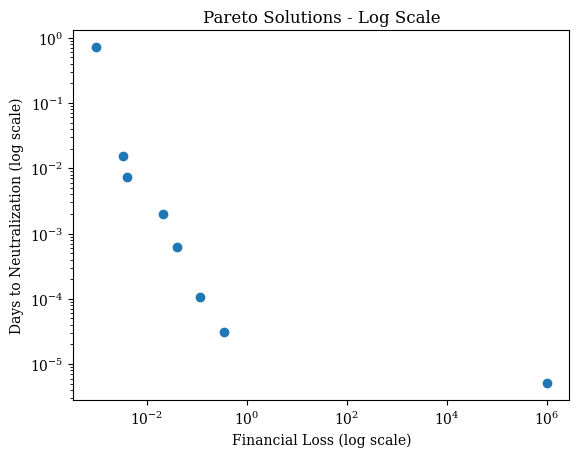

In [43]:
# display pareto solutions on a log scale 
f1 = res.F[:, 0]  # financial loss
f2 = res.F[:, 1]  # days to neutralization

plt.scatter(f1, f2
            )
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Financial Loss (log scale)")
plt.ylabel("Days to Neutralization (log scale)")
plt.title("Pareto Solutions - Log Scale")
plt.show()

next steps: 
- ensure that the predictions are never negative using log transformations; retrain regrs using  target transform (log1p) so the model predicts log(days+1); invert with expm1 in objective which guarantees non-negative outputs:

- If the surrogate is poor, consider a non-linear regressor for y2 (GradientBoostingRegressor, RandomForest) or Gaussian Process / Bayesian surrogate for MOO.